
---

# ***`Feature Scaling : Standardization`***

---

You Need to Use Standard Scaler in Following Algorithms.

|Algorithm(s)|Reason of applying feature scaling|
|---|---|
|***`K-Means`***|Use the Euclidean distance measure.|
|***`K-Nearest-Neighbours`***|Measure the distances between pairs of samples and these distances are influenced by the measurement units|
|***`Principal Component Analysis (PCA)`***|Try to get the feature with maximum variance|
|***`Artificial Neural Network`***|Apply Gradient Descent|
|***`Gradient Descent`***|Theta calculation becomes faster after feature scaling and the learning rate in the update equation of Stochastic Gradient Descent is the same for every parameter|

Where standard Scaling Not Needed.
>**Decision Tree**

>**Random Forest**

>**XGBOOST** 



#### **Import Libraries**

In [100]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

#### **Load the Dataset**

In [101]:
df = pd.read_csv(r"https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day24-standardization/Social_Network_Ads.csv")

df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [102]:
# This line selects all rows of the DataFrame 'df' and keeps only the columns starting from the third column onward.
# The 'iloc' method is used for integer-location based indexing, where ':' indicates all rows and '2:' indicates columns from index 2 to the end.
df=df.iloc[:,2:]

In [103]:
df.sample(5)

,Age,EstimatedSalary,Purchased
17,45,26000,1
4,19,76000,0
335,36,54000,0
138,28,59000,0
74,32,18000,0


#### **Train test Split**

In [104]:
# Split the DataFrame 'df' into training and testing sets.
# 'Purchased' is the target variable, while all other columns are features.

X_train, X_test, y_train, y_test = train_test_split(
    df.drop("Purchased", axis=1),  # Features: all columns except 'Purchased'
    df["Purchased"],                # Target variable: 'Purchased'
    test_size=0.3,                 # 30% of the data will be used for testing
    random_state=0                 # Seed for reproducibility
)

# Output the shapes of the training and testing feature sets
X_train.shape, X_test.shape

((280, 2), (120, 2))

In [105]:
X_train.sample(6)

,Age,EstimatedSalary
46,25,79000
93,29,28000
77,22,27000
289,37,78000
375,46,32000
262,55,125000


#### **StandardScaler**

In [106]:
# Initialize the StandardScaler to standardize the features by removing the mean and scaling to unit variance.
scaler = StandardScaler()

# Fit the scaler on the training data to compute the mean and standard deviation.
scaler.fit(X_train)

# Transform the training data using the fitted scaler to standardize the features.
X_train_scaled = scaler.transform(X_train)

# Transform the testing data using the same scaler to ensure consistent scaling.
X_test_scaled = scaler.transform(X_test)

In [107]:
X_train_scaled[0:11] # first 10 values 

array([[-1.1631724 , -1.5849703 ],
       [ 2.17018137,  0.93098672],
       [ 0.0133054 ,  1.22017719],
       [ 0.20938504,  1.07558195],
       [ 0.40546467, -0.48604654],
       [-0.28081405, -0.31253226],
       [ 0.99370357, -0.8330751 ],
       [ 0.99370357,  1.8563962 ],
       [ 0.0133054 ,  1.24909623],
       [-0.86905295,  2.26126285],
       [-1.1631724 , -1.5849703 ]])

In [108]:
X_test_scaled[0:11] # first 10 values 

array([[-0.77101313,  0.49720103],
       [ 0.0133054 , -0.57280368],
       [-0.28081405,  0.15017248],
       [-0.77101313,  0.26584866],
       [-0.28081405, -0.57280368],
       [-1.06513258, -1.44037507],
       [-0.67297331, -1.5849703 ],
       [-0.18277423,  2.14558666],
       [-1.94749093, -0.05226085],
       [ 0.89566375, -0.775237  ],
       [-0.77101313, -0.60172273]])

In [109]:
# Convert the scaled training data back into a DataFrame, using the original column names from X_train.
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# Convert the scaled testing data back into a DataFrame, using the original column names from X_test.
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [110]:
print("-"*40)
print(f"Before Standard Scaler Transformation \n\n{X_train.sample(5)}")
print("-"*40)
print(f"After Standard Scaler Transformation \n\n{X_train_scaled.sample(5)}")
print("-"*40)

----------------------------------------
Before Standard Scaler Transformation 

     Age  EstimatedSalary
69    31            68000
88    26            81000
212   59            42000
317   35            55000
228   40            72000
----------------------------------------
After Standard Scaler Transformation 

          Age  EstimatedSalary
28   0.797624         0.265849
272  0.405465        -0.457127
20  -0.476894        -0.023342
186 -0.869053         0.381525
275  0.993704        -1.151185
----------------------------------------


In [111]:
# Generate descriptive statistics for the scaled training data.
# The 'describe()' method provides a summary of the central tendency, dispersion, and shape of the dataset's distribution.
# 'np.round(..., 1)' rounds the results to one decimal place for easier readability.
np.round(X_train_scaled.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


- We can see that `mean` is `0` and `std` is `1` due to impact of StandardScaler.

#### **Effects of StandardScaler**

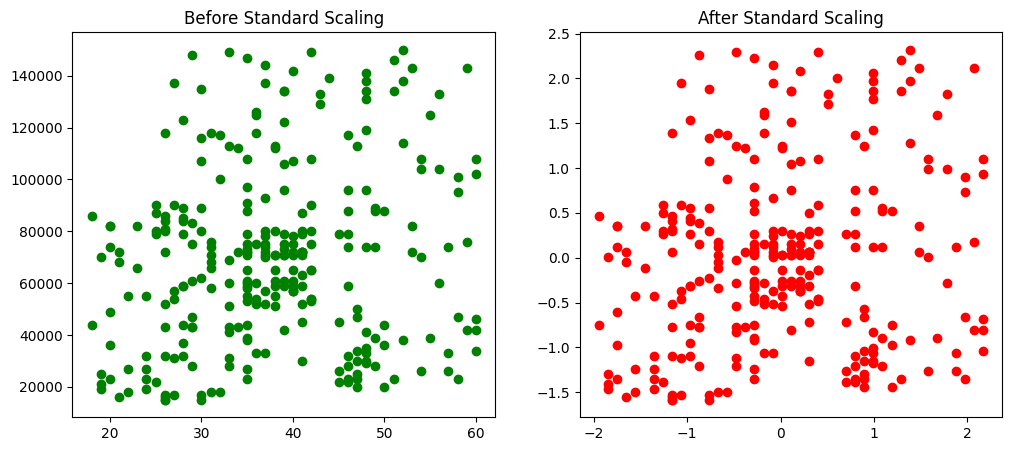

In [112]:
# Create a figure with two subplots side by side, with a specified size of 12x5 inches.
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Scatter plot of 'Age' vs 'EstimatedSalary' from the original training data (before scaling).
ax1.scatter(X_train['Age'], X_train['EstimatedSalary'], color='g')
ax1.set_title("Before Standard Scaling")  # Set the title for the first subplot.

# Scatter plot of 'Age' vs 'EstimatedSalary' from the scaled training data (after scaling), in red.
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'], color='r')
ax2.set_title("After Standard Scaling")  # Set the title for the second subplot.

# Display the plots.
plt.show()

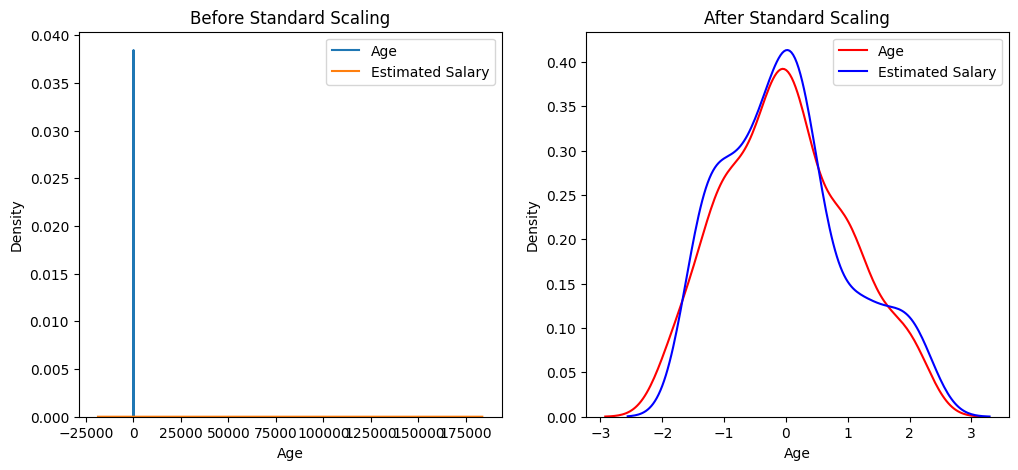

In [113]:
# Create a figure with two subplots side by side, with a specified size of 12x5 inches.
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Set the title for the first subplot.
ax1.set_title("Before Standard Scaling")

# Plot the KDE (Kernel Density Estimate) for 'Age' and 'EstimatedSalary' in the original data.
sns.kdeplot(X_train['Age'], ax=ax1, label='Age')  # Added label for clarity
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1, label='Estimated Salary')  # Added label for clarity
ax1.legend()  # Show legend for the first plot.

# Set the title for the second subplot.
ax2.set_title("After Standard Scaling")

# Plot the KDE for 'Age' and 'EstimatedSalary' in the scaled data.
sns.kdeplot(X_train_scaled['Age'], ax=ax2, label='Age', color='r')  # Added label and color for clarity
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2, label='Estimated Salary', color='b')  # Added label and color for clarity
ax2.legend()  # Show legend for the second plot.

# Display the plots.
plt.show()

#### **Comparison of Distribution**

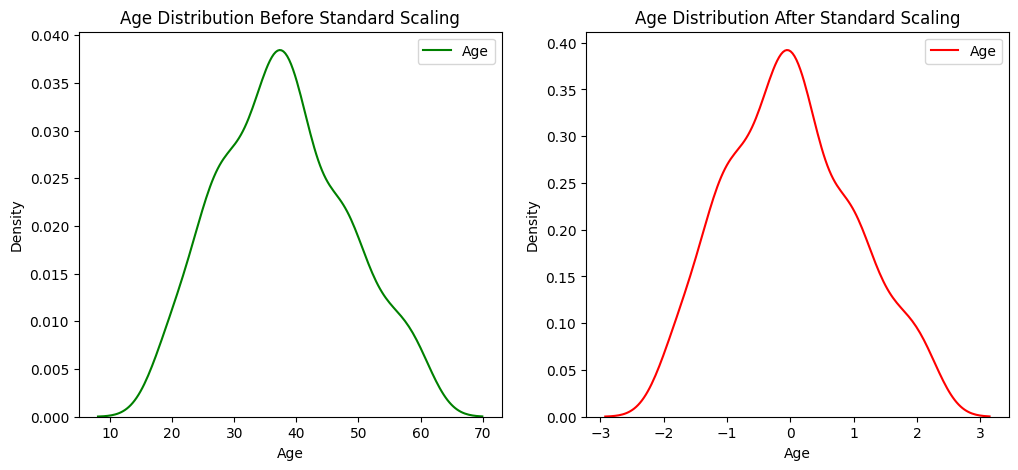

In [114]:
# Create a figure with two subplots side by side, with a specified size of 12x5 inches.
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Set the title for the first subplot.
ax1.set_title("Age Distribution Before Standard Scaling")

# Plot the KDE (Kernel Density Estimate) for 'Age' and 'EstimatedSalary' in the original data.
sns.kdeplot(X_train['Age'], ax=ax1, label='Age', color='g')  # Added label for clarity
ax1.legend()  # Show legend for the first plot.

# Set the title for the second subplot.
ax2.set_title("Age Distribution After Standard Scaling")

# Plot the KDE for 'Age' and 'EstimatedSalary' in the scaled data.
sns.kdeplot(X_train_scaled['Age'], ax=ax2, label='Age', color='r')  # Added label and color for clarity
ax2.legend()  # Show legend for the second plot.

# Display the plots.
plt.show()

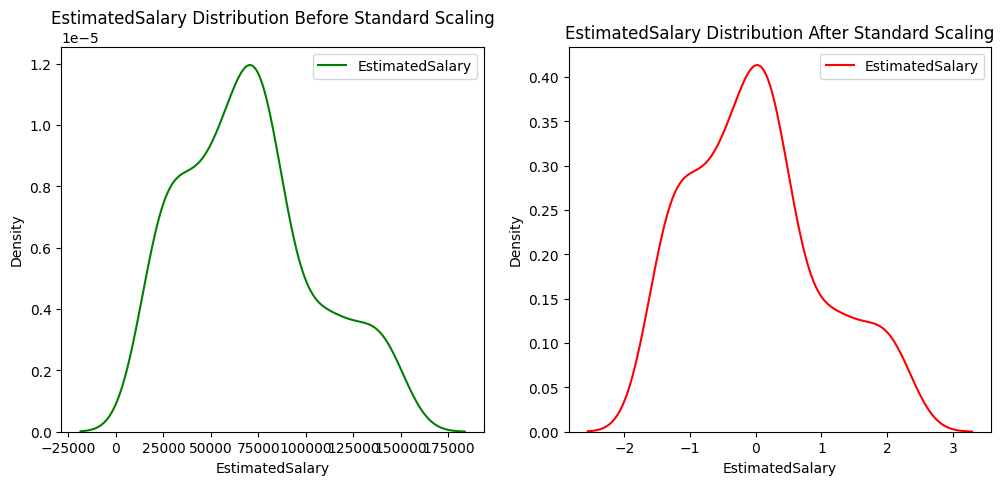

In [115]:
# Create a figure with two subplots side by side, with a specified size of 12x5 inches.
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Set the title for the first subplot.
ax1.set_title("EstimatedSalary Distribution Before Standard Scaling")

# Plot the KDE (Kernel Density Estimate) for 'EstimatedSalary' and 'EstimatedSalary' in the original data.
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1, label='EstimatedSalary',color='g')  # Added label for clarity
ax1.legend()  # Show legend for the first plot.

# Set the title for the second subplot.
ax2.set_title("EstimatedSalary Distribution After Standard Scaling")

# Plot the KDE for 'EstimatedSalary' and 'EstimatedSalary' in the scaled data.
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2, label='EstimatedSalary', color='r')  # Added label and color for clarity
ax2.legend()  # Show legend for the second plot.

# Display the plots.
plt.show()

#### **Why Scaling Is Important ?**

In [116]:
# Initialize two instances of Logistic Regression: one for the original data and one for the scaled data.
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [117]:
# Fit the Logistic Regression model on the original training data.
lr.fit(X_train, y_train)

# Fit the Logistic Regression model on the scaled training data.
lr_scaled.fit(X_train_scaled, y_train)

LogisticRegression()

In [118]:
# Predict the target variable on the test set using the model trained on the original data.
y_pred = lr.predict(X_test)

# Predict the target variable on the test set using the model trained on the scaled data.
y_pred_scaled = lr_scaled.predict(X_test_scaled)

In [119]:
# Calculate and print the accuracy of the model trained on the original data.
print("Actual Accuracy:", accuracy_score(y_test, y_pred))

# Calculate and print the accuracy of the model trained on the scaled data.
print("Scaled Accuracy:", accuracy_score(y_test, y_pred_scaled))

Actual Accuracy: 0.875
Scaled Accuracy: 0.8666666666666667


##### **Decision Tree**

- Has no Impact Of Scaling.

In [120]:
# Initialize two instances of Decision Tree Classifier: one for the original data and one for the scaled data.
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

In [121]:
# Fit the Decision Tree model on the original training data.
dt.fit(X_train, y_train)

# Fit the Decision Tree model on the scaled training data.
dt_scaled.fit(X_train_scaled, y_train)

DecisionTreeClassifier()

In [122]:
# Predict the target variable on the test set using the model trained on the original data.
y_pred = dt.predict(X_test)

# Predict the target variable on the test set using the model trained on the scaled data.
y_pred_scaled = dt_scaled.predict(X_test_scaled)

In [123]:
# Predict the target variable on the test set using the model trained on the original data.
y_pred = dt.predict(X_test)

# Predict the target variable on the test set using the model trained on the scaled data.
y_pred_scaled = dt_scaled.predict(X_test_scaled)

In [124]:
# Calculate and print the accuracy of the model trained on the original data.
print("Actual Accuracy:", accuracy_score(y_test, y_pred))

# Calculate and print the accuracy of the model trained on the scaled data.
print("Scaled Accuracy:", accuracy_score(y_test, y_pred_scaled))

Actual Accuracy: 0.875
Scaled Accuracy: 0.8666666666666667


In [125]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


### **Effect Of Outliers**

In [126]:
# Assuming `df` is your existing DataFrame
new_data = pd.DataFrame({
    'Age': [5, 90, 95],
    'EstimatedSalary': [1000, 250000, 350000],
    'Purchased': [0, 1, 1]
})

# Use pd.concat instead of append
df = pd.concat([df, new_data], ignore_index=True)

In [127]:
df.sample(5)

,Age,EstimatedSalary,Purchased
351,37,75000,0
55,24,55000,0
376,46,74000,0
205,47,47000,0
140,19,85000,0


In [128]:
# Split the DataFrame 'df' into training and testing sets.
# 'Purchased' is the target variable, while all other columns are features.

X_train, X_test, y_train, y_test = train_test_split(
    df.drop("Purchased", axis=1),  # Features: all columns except 'Purchased'
    df["Purchased"],                # Target variable: 'Purchased'
    test_size=0.3,                 # 30% of the data will be used for testing
    random_state=0                 # Seed for reproducibility
)

# Output the shapes of the training and testing feature sets
X_train.shape, X_test.shape

((282, 2), (121, 2))

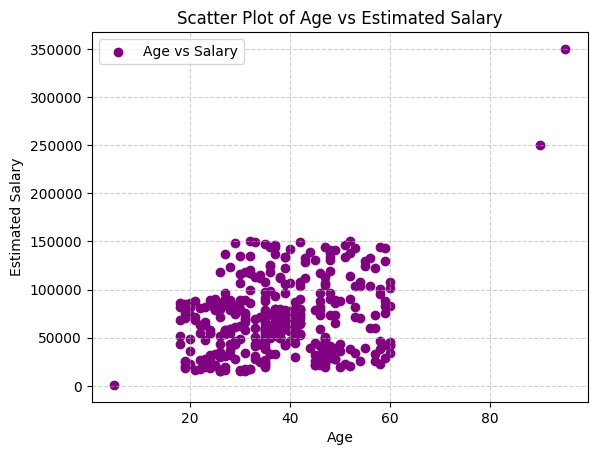

In [129]:
# Scatter plot with enhancements
plt.scatter(df['Age'], df['EstimatedSalary'], color='purple', label='Age vs Salary')  # Add color and legend label
plt.title('Scatter Plot of Age vs Estimated Salary')  # Add title
plt.xlabel('Age')  # Add x-axis label
plt.ylabel('Estimated Salary')  # Add y-axis label
plt.legend()  # Add legend
plt.grid(True, linestyle='--', alpha=0.6)  # Optional: Add gridlines for better readability
plt.show()

In [130]:
# Initialize the StandardScaler to standardize the features by removing the mean and scaling to unit variance.
scaler = StandardScaler()

# Fit the scaler on the training data to compute the mean and standard deviation.
scaler.fit(X_train)

# Transform the training data using the fitted scaler to standardize the features.
X_train_scaled = scaler.transform(X_train)

# Transform the testing data using the same scaler to ensure consistent scaling.
X_test_scaled = scaler.transform(X_test)

In [131]:
# Convert the scaled training data back into a DataFrame, using the original column names from X_train.
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# Convert the scaled testing data back into a DataFrame, using the original column names from X_test.
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

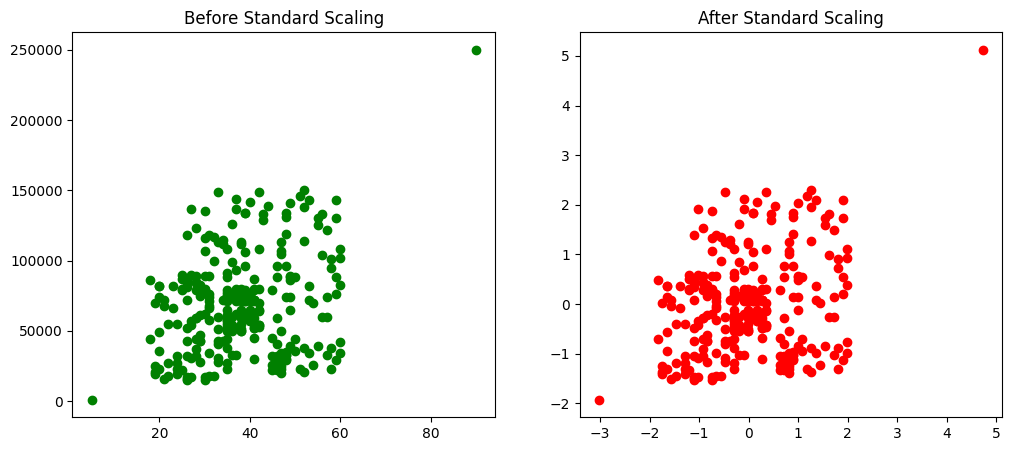

In [132]:
# Create a figure with two subplots side by side, with a specified size of 12x5 inches.
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Scatter plot of 'Age' vs 'EstimatedSalary' from the original training data (before scaling).
ax1.scatter(X_train['Age'], X_train['EstimatedSalary'], color='g')
ax1.set_title("Before Standard Scaling")  # Set the title for the first subplot.

# Scatter plot of 'Age' vs 'EstimatedSalary' from the scaled training data (after scaling), in red.
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'], color='r')
ax2.set_title("After Standard Scaling")  # Set the title for the second subplot.

# Display the plots.
plt.show()

- We can see that outliers are present and we need to deal with it explicitly.

---